In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
# Caminhos padrões para os arquivos e pastas
caminho_processed = "../dados/processed"
caminho_gold = "../dados/gold"

In [3]:
# Visualização das colunas de dados 'float' para somente 2 casas decimais
pd.set_option('display.float_format', '{:,.2f}'.format)

In [4]:
df_analitico = pd.read_parquet(os.path.join(caminho_gold, "df_gold.parquet"))

# --- SOLVÊNCIA & CAPACIDADE ---
# Alavancagem Inversa -> Quanto do Ativo é dinheiro dos sócios?
df_analitico['kpi_basileia'] = df_analitico['patrimonio_liquido'] / df_analitico['ativo_total']

# --- RENTABILIDADE ---
# ROE (Return on Equity)
df_analitico['kpi_roe'] = df_analitico['lucro_liquido'] / df_analitico['patrimonio_liquido']

# --- QUALIDADE ---
# Dependência de "Outras Receitas".
# Se o banco depende muito de receitas não-operacionais, isso é não recorrente.
# Fórmula: Outras Receitas / (Total de Receitas Operacionais)
df_analitico['receita_total_estimada'] = df_analitico['resultado_intermediacao'] + df_analitico['outras_receitas_despesas'] + df_analitico['resultado_pagamentos'].fillna(0)

df_analitico['kpi_qualidade_lucro'] = df_analitico['outras_receitas_despesas'] / df_analitico['receita_total_estimada']

# --- VOLUMETRIA ---
# Tamanho do Banco (Log) para separar Pequenos de Gigantes
df_analitico['tamanho_log'] = np.log10(df_analitico['ativo_total'])

df_analitico.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17170 entries, 0 to 17169
Data columns (total 41 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   instituicao                                  17170 non-null  string        
 1   data_base                                    17170 non-null  datetime64[ns]
 2   codigo_bacen                                 17170 non-null  Int64         
 3   conglomerado                                 8373 non-null   category      
 4   tcb                                          17170 non-null  category      
 5   tc                                           17170 non-null  Int64         
 6   ti                                           17170 non-null  Int64         
 7   cidade                                       17170 non-null  string        
 8   uf                                           17170 non-null  category      


c:\Users\Thiag\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
#Código para auxiliar a encontrar as intituições. Pelo fato de ter várias no conglomerado financeiro
filtro_nome = df_analitico['instituicao'].str.contains('INTER', case=False, na=False)
filtro_data = df_analitico['data_base'] == '2022-12-01'

bancosss = df_analitico[filtro_nome & filtro_data]

resultado = bancosss[['data_base','instituicao','ativo_total']]

resultado

,data_base,instituicao,ativo_total
29,2022-12-01,BANCO RABOBANK INTERNATIONAL BRASIL S.A.,"47,739,522.00"
31,2022-12-01,BANCO INTER S.A.,"45,892,486.00"
44,2022-12-01,PAGSEGURO INTERNET INSTITUIÇÃO DE PAGAMENTO S.A.,"27,859,972.00"
101,2022-12-01,COOPERATIVA CENTRAL DE CRÉDITO COM INTERAÇÃO S...,"9,599,095.00"
195,2022-12-01,COOPERATIVA CENTRAL DE CRÉDITO RURAL COM INTER...,"3,379,898.00"
...,...,...,...
1036,2022-12-01,COOPERATIVA DE CRÉDITO E ECONOMIA COM INTERAÇÃ...,"42,576.00"
1098,2022-12-01,DISTRIBUIDORA INTERCAP DE TÍTULOS E VALORES MO...,"24,113.00"
1139,2022-12-01,COOPERATIVA DE ECONOMIA E CRÉDITO MÚTUO DOS FU...,"17,241.00"
1141,2022-12-01,INTERCAM CORRETORA DE CÂMBIO LTDA.,"17,207.00"


In [6]:
bancos_comparacao = [
    'BANCO PAN S.A.',                # Benchmark de escala no Varejo/Consignado
    'BANCO DAYCOVAL S.A.',           # Referência de solidez/risco em Bancos Médios
    'BANCO BMG S.A.',                # Concorrente direto tradicional em Consignado
    'BANCO ABC BRASIL S.A.',         # Comparável em volume de Ativos (Corporate)
    'BANCO INTER S.A.',              # Comparativo para a vertente digital (Will Bank)
    'BANCO MERCANTIL DO BRASIL S.A', # Especialista no nicho INSS/50+
    'BANCO AGIBANK S.A.',            # Modelo de crescimento agressivo em baixa renda
    'BRB - BANCO DE BRASILIA S.A.'   # Porte similar e histórico de parcerias
]

bancos = [
    'BANCO MASTER S/A',              # O Banco analisado
    'BANCO PAN S.A.',                # Benchmark de escala no Varejo/Consignado
    'BANCO DAYCOVAL S.A.',           # Referência de solidez/risco em Bancos Médios
    'BANCO BMG S.A.',                # Concorrente direto tradicional em Consignado
    'BANCO ABC BRASIL S.A.',         # Comparável em volume de Ativos (Corporate)
    'BANCO INTER S.A.',              # Comparativo para a vertente digital (Will Bank)
    'BANCO MERCANTIL DO BRASIL S.A', # Especialista no nicho INSS/50+
    'BANCO AGIBANK S.A.',            # Modelo de crescimento agressivo em baixa renda
    'BRB - BANCO DE BRASILIA S.A.'   # Porte similar e histórico de parcerias
]

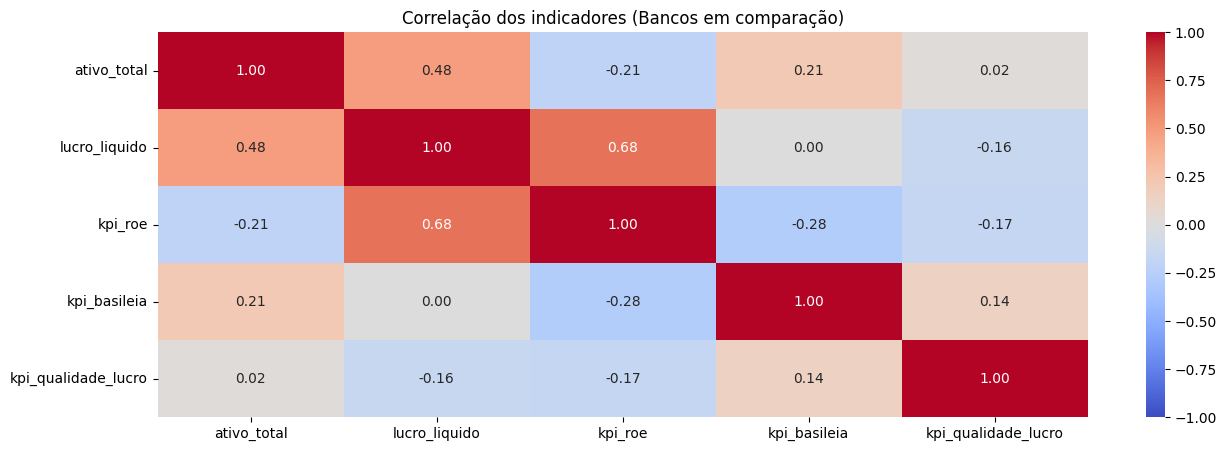

In [7]:
colunas_visualizar = [
    'instituicao',
    'ativo_total',
    'lucro_liquido',
    'kpi_roe',
    'kpi_basileia',
    'kpi_qualidade_lucro'
]

df_bancos = df_analitico.loc[df_analitico['instituicao'].isin(bancos_comparacao),colunas_visualizar].copy()


correlação_bancos = df_bancos.corr(
    method='pearson',
    numeric_only=True
)

plt.figure(figsize=(15,5))
sns.heatmap(
    correlação_bancos,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0
)
plt.title('Correlação dos indicadores (Bancos em comparação)')
plt.show()

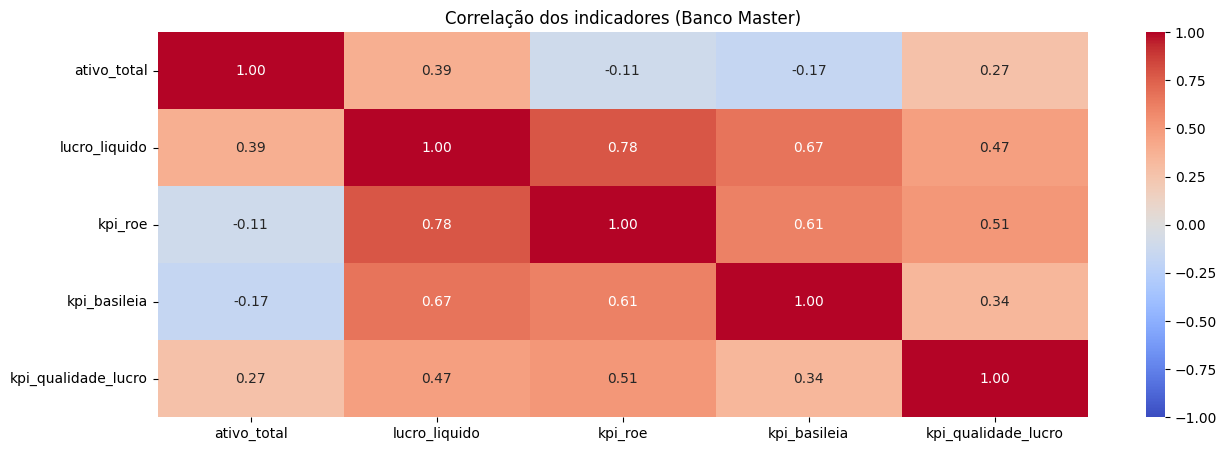

In [8]:
df_master = df_analitico.loc[df_analitico['instituicao'] == 'BANCO MASTER S/A',colunas_visualizar].copy()

correlação_master = df_master.corr(
    method='pearson',
    numeric_only=True
)

plt.figure(figsize=(15,5))
sns.heatmap(
    correlação_master,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0
)
plt.title('Correlação dos indicadores (Banco Master)')
plt.show()

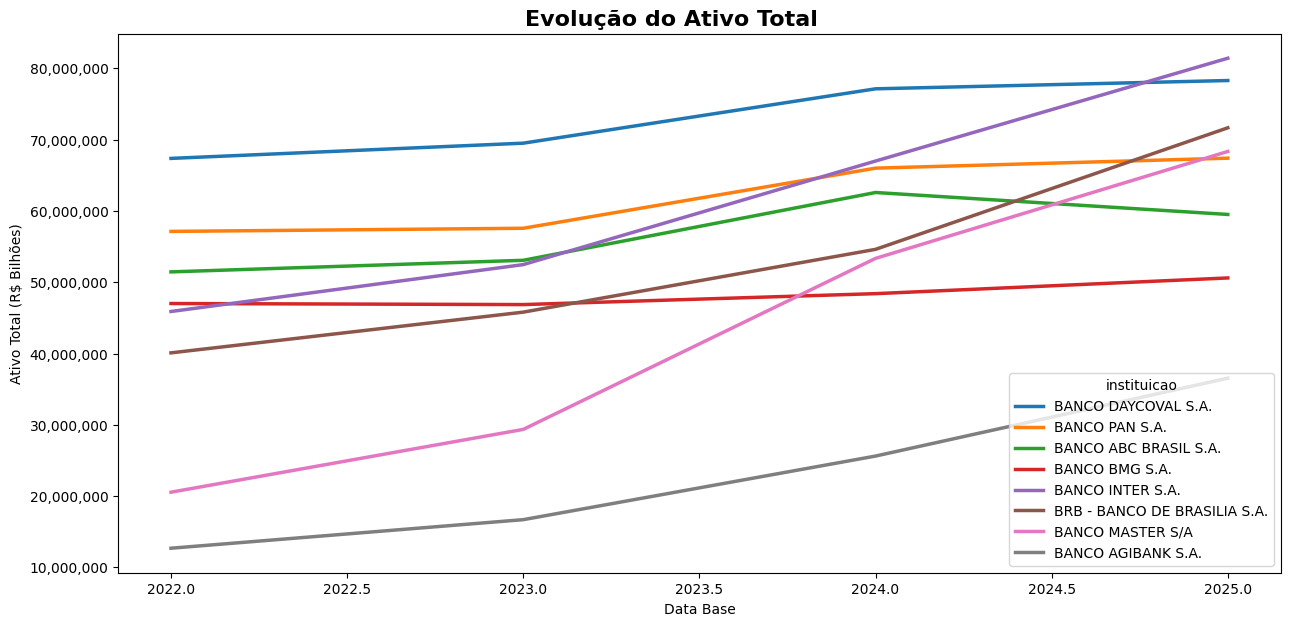

In [9]:
df_analitico['Year'] = df_analitico['data_base'].dt.year

df_bancos = df_analitico.loc[df_analitico['instituicao'].isin(bancos)].copy()

plt.figure(figsize=(15,7))

sns.lineplot(
    data=df_bancos,
    x='Year',
    y='ativo_total',
    hue='instituicao',
    linewidth=2.5,
    errorbar=None
)


ax = plt.gca() # Pega o eixo atual
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.title('Evolução do Ativo Total', fontsize=16, fontweight='bold', loc='left', x=0.35)
plt.ylabel('Ativo Total (R$ Bilhões)')
plt.xlabel('Data Base')
plt.show()

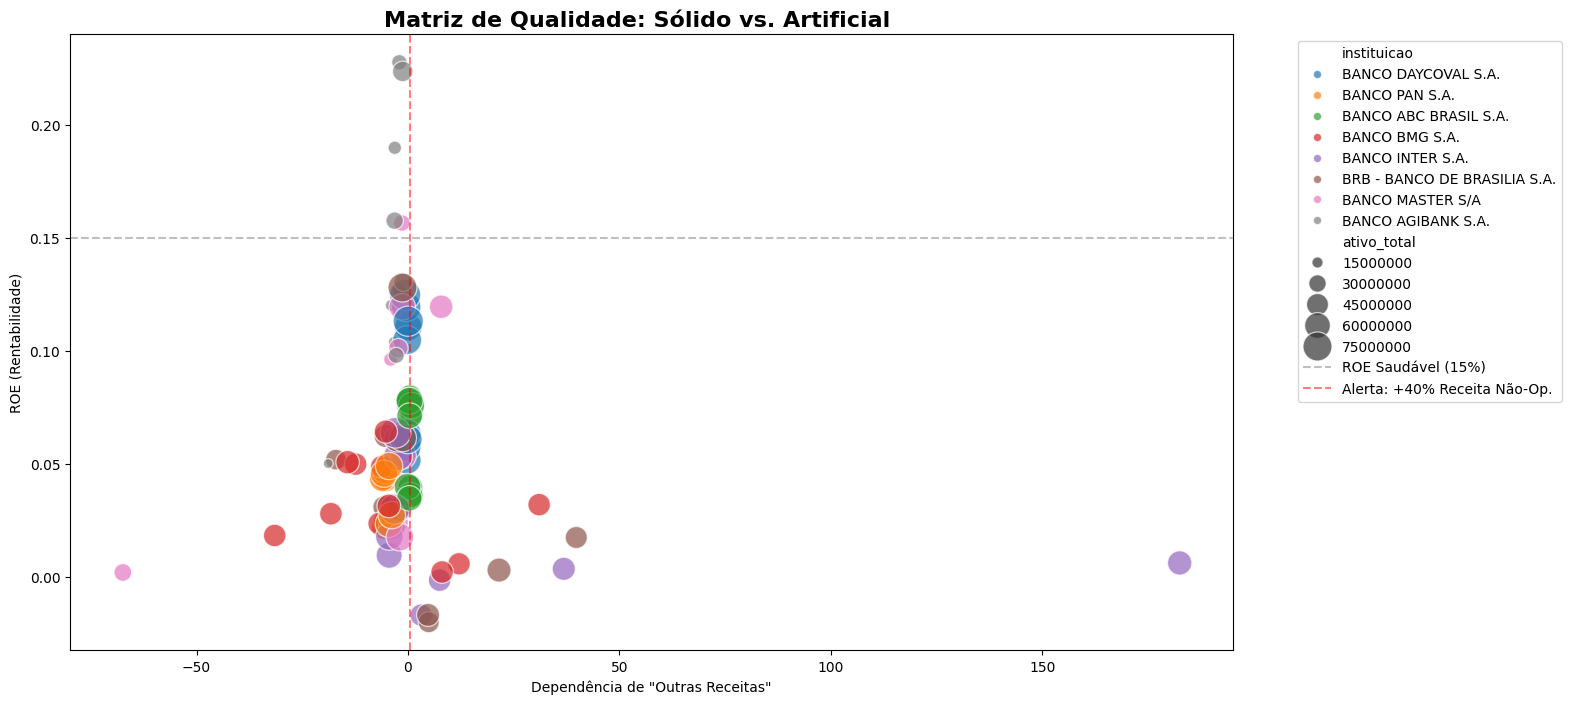

In [10]:
plt.figure(figsize=(15, 8))

# Vamos pegar a média do último ano para não ficar muito poluído
df_recente = df_bancos[df_bancos['data_base'] >= '2024-01-01'].copy()

sns.scatterplot(
    data=df_bancos,
    x='kpi_qualidade_lucro',
    y='kpi_roe',
    hue='instituicao',
    size='ativo_total',
    sizes=(50, 500),
    alpha=0.7,
    palette='tab10'
)

# Linhas de Referência (Quadrantes)
plt.axhline(y=0.15, color='gray', linestyle='--', alpha=0.5, label='ROE Saudável (15%)')
plt.axvline(x=0.40, color='red', linestyle='--', alpha=0.5, label='Alerta: +40% Receita Não-Op.') 

plt.title('Matriz de Qualidade: Sólido vs. Artificial', fontsize=16, fontweight='bold', loc='left', x=0.27)
plt.ylabel('ROE (Rentabilidade)')
plt.xlabel('Dependência de "Outras Receitas"')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

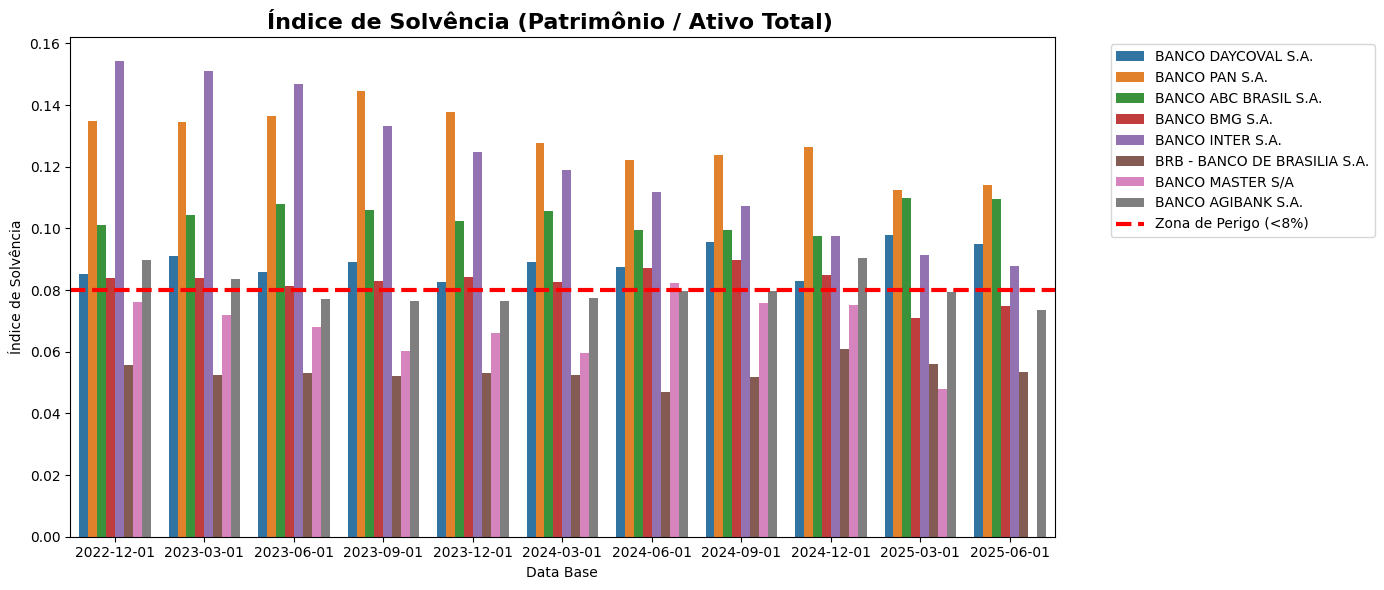

In [11]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_bancos,
    x='data_base',
    y='kpi_basileia',
    hue='instituicao'
)

plt.title('Índice de Solvência (Patrimônio / Ativo Total)', fontsize=16, fontweight='bold', loc='left', x=0.2)
plt.ylabel('Índice de Solvência')
plt.xlabel('Data Base')

# Linha de Perigo (Bancos costumam quebrar abaixo de 5-8% de capital próprio real)
plt.axhline(y=0.08, color='red', linestyle='--', linewidth=3, label='Zona de Perigo (<8%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()